In [1]:
import arviz as az
import bayesflow as bf
import blackjax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from confrdm.data import load_hdf5
from confrdm_jax.plots import  plot_data_hist

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
INFO:2026-02-03 18:31:07,398:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## RDM

In [2]:
def reshape_posterior_samples(samples):
    return np.reshape(samples, (samples.shape[0], -1, samples.shape[-1]))

In [3]:
param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

results = load_hdf5("../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=200000/parameter_recovery.hdf5")
posterior_samples_chains_approx = results["samples_approx"]
posterior_samples_approx = reshape_posterior_samples(posterior_samples_chains_approx)

posterior_samples_chains_ref = results["samples_ref"]
posterior_samples_ref = reshape_posterior_samples(posterior_samples_chains_ref)

prior_samples = results["true_params"]
data = results["data"]

In [4]:
posterior_samples_chains_approx.shape

(50, 1000, 4, 5)

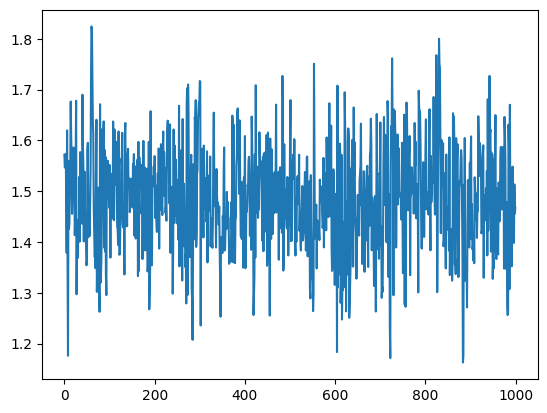

In [5]:
plt.plot(posterior_samples_chains_approx[0, :, 0, 1])

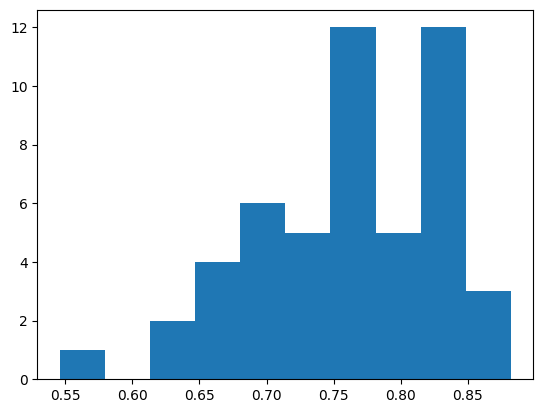

In [6]:
plt.hist(data[..., 1].mean(axis=1));

In [7]:
psrf_approx = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_approx, chain_axis=2, sample_axis=1)
is_converged_approx = np.all(np.isfinite(psrf_approx) & (psrf_approx < 1.01), axis=1)
is_converged_approx.mean()

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/blackjax/diagnostics.py:72: RuntimeWarning: invalid value encountered in divide
  (between_chain_variance / within_chain_variance + num_samples - 1)


Array(0.91999996, dtype=float32)

In [8]:
psrf_ref = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_ref, chain_axis=2, sample_axis=1)
is_converged_ref = np.all(np.isfinite(psrf_ref) & (psrf_ref < 1.01), axis=1)
is_converged_ref.mean()

Array(0.91999996, dtype=float32)

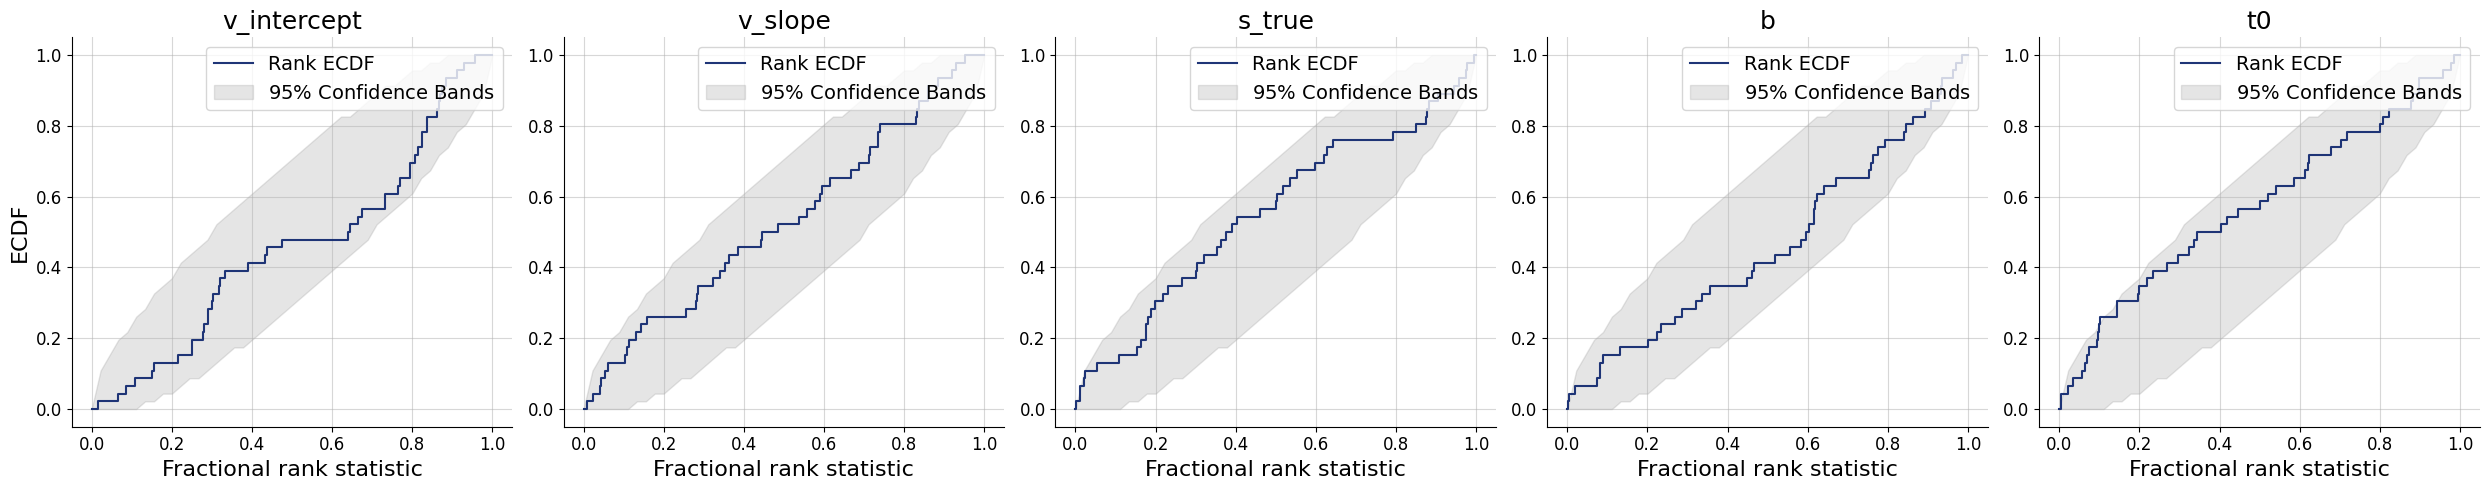

In [9]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/rdm_ecdf_approx.png")

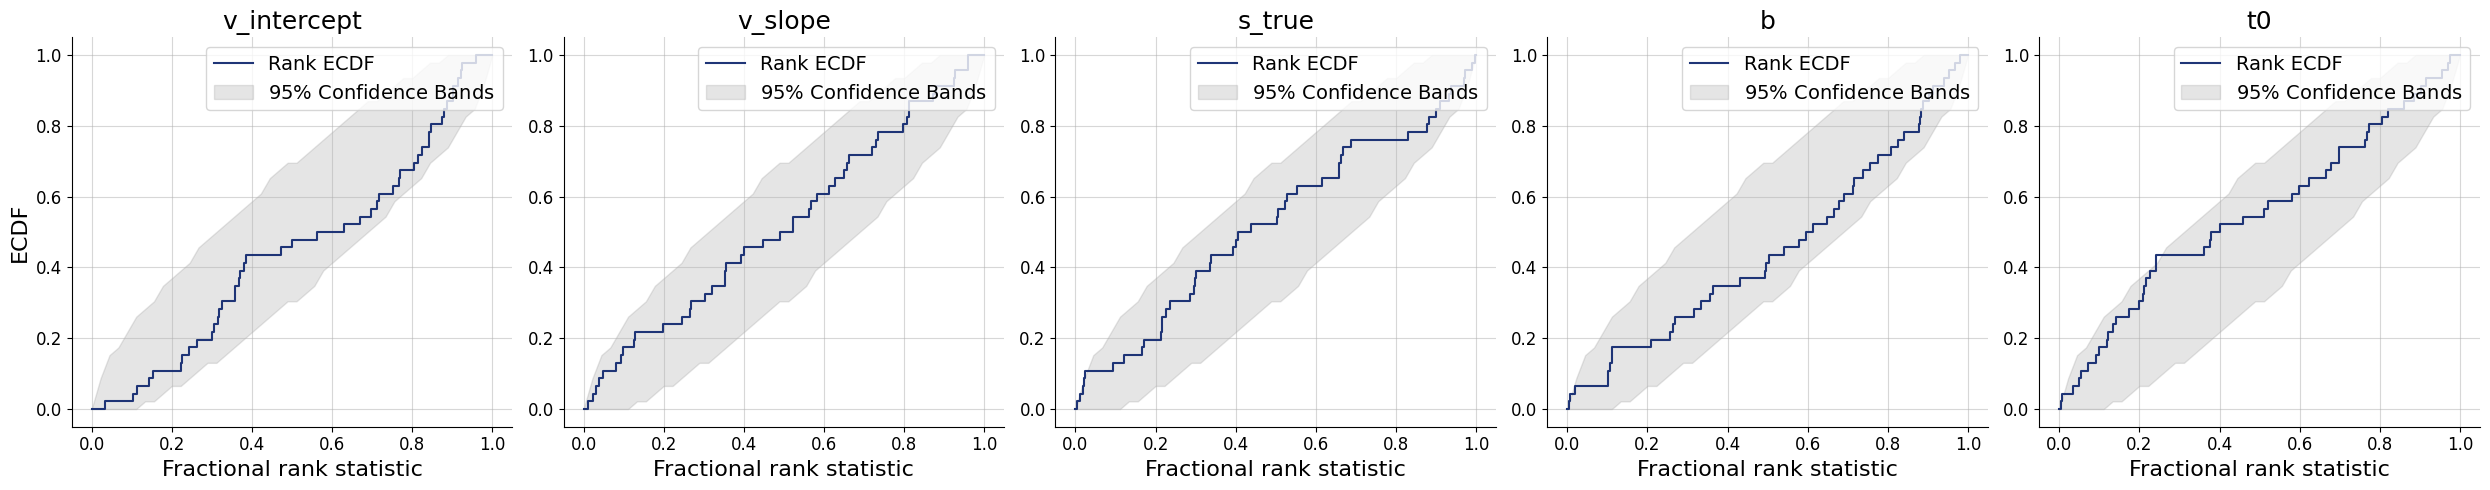

In [10]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_ref[is_converged_ref], prior_samples[is_converged_ref], variable_names=param_names)
plt.savefig("parameter_recovery/rdm_ecdf_ref.png")

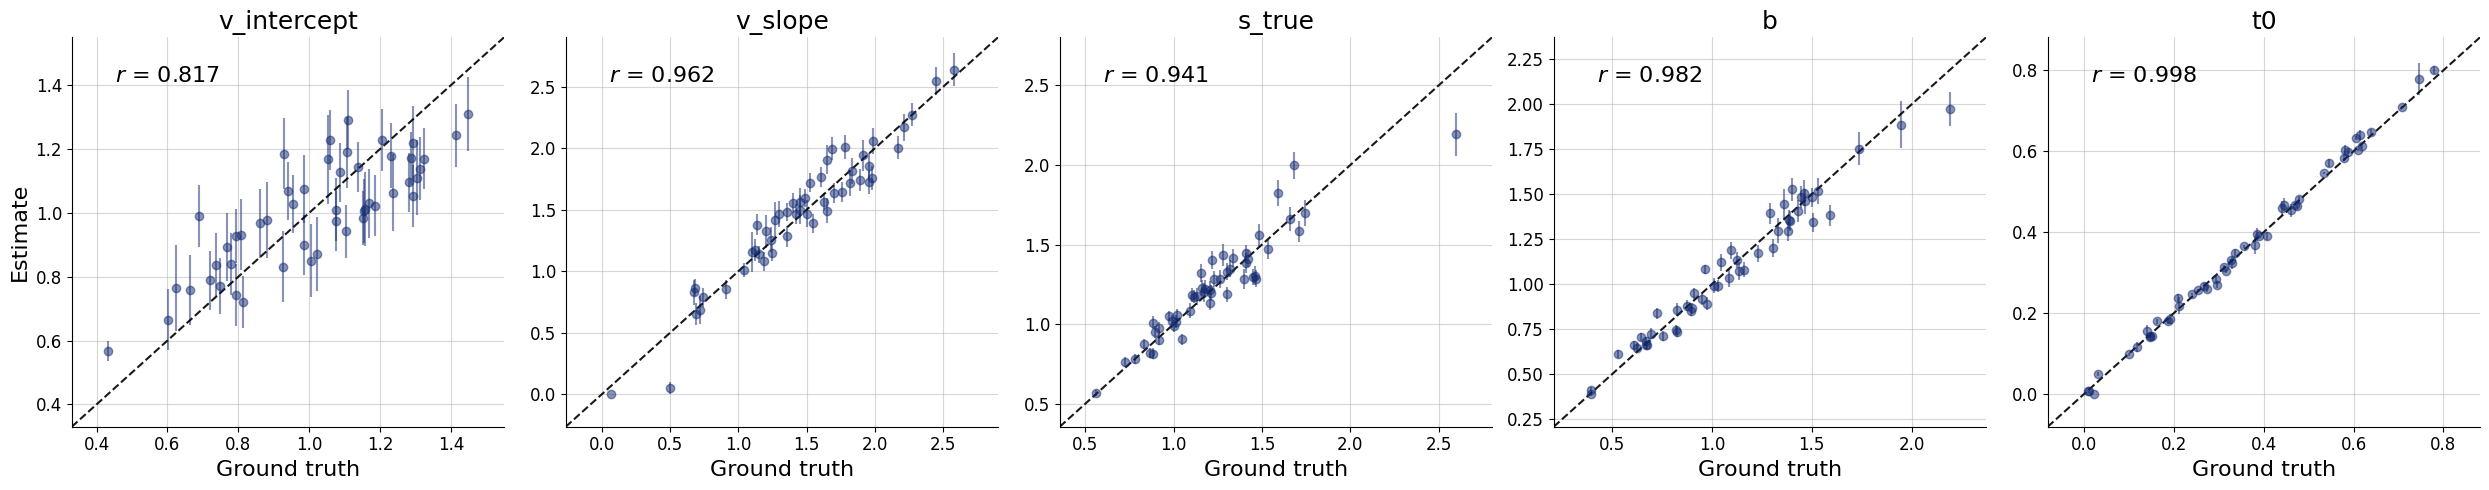

In [11]:
_ = bf.diagnostics.recovery(posterior_samples_approx, prior_samples, variable_names=param_names)
plt.savefig("parameter_recovery/rdm_recovery_approx.png")

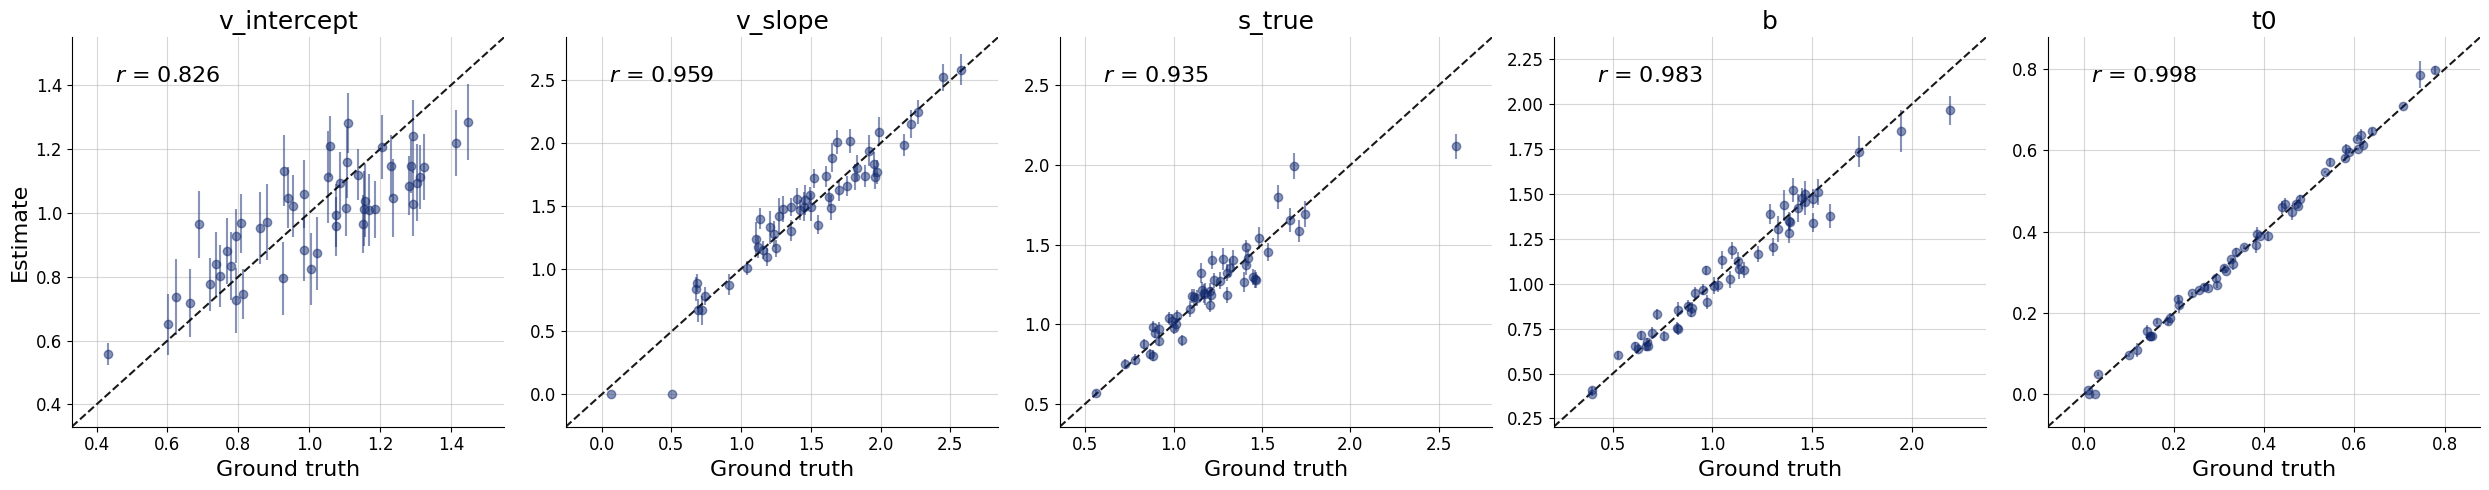

In [12]:
_ = bf.diagnostics.recovery(posterior_samples_ref, prior_samples, variable_names=param_names)
plt.savefig("parameter_recovery/rdm_recovery_ref.png")

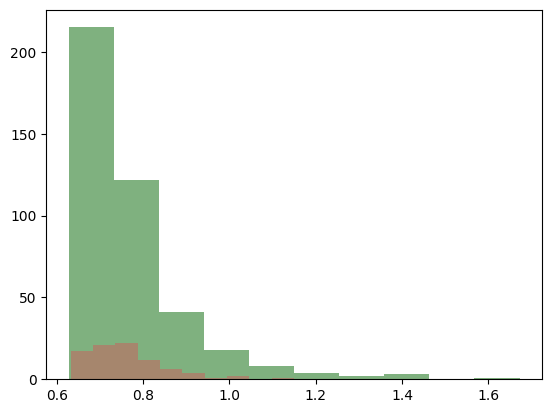

In [13]:
plot_data_hist(data[2]);

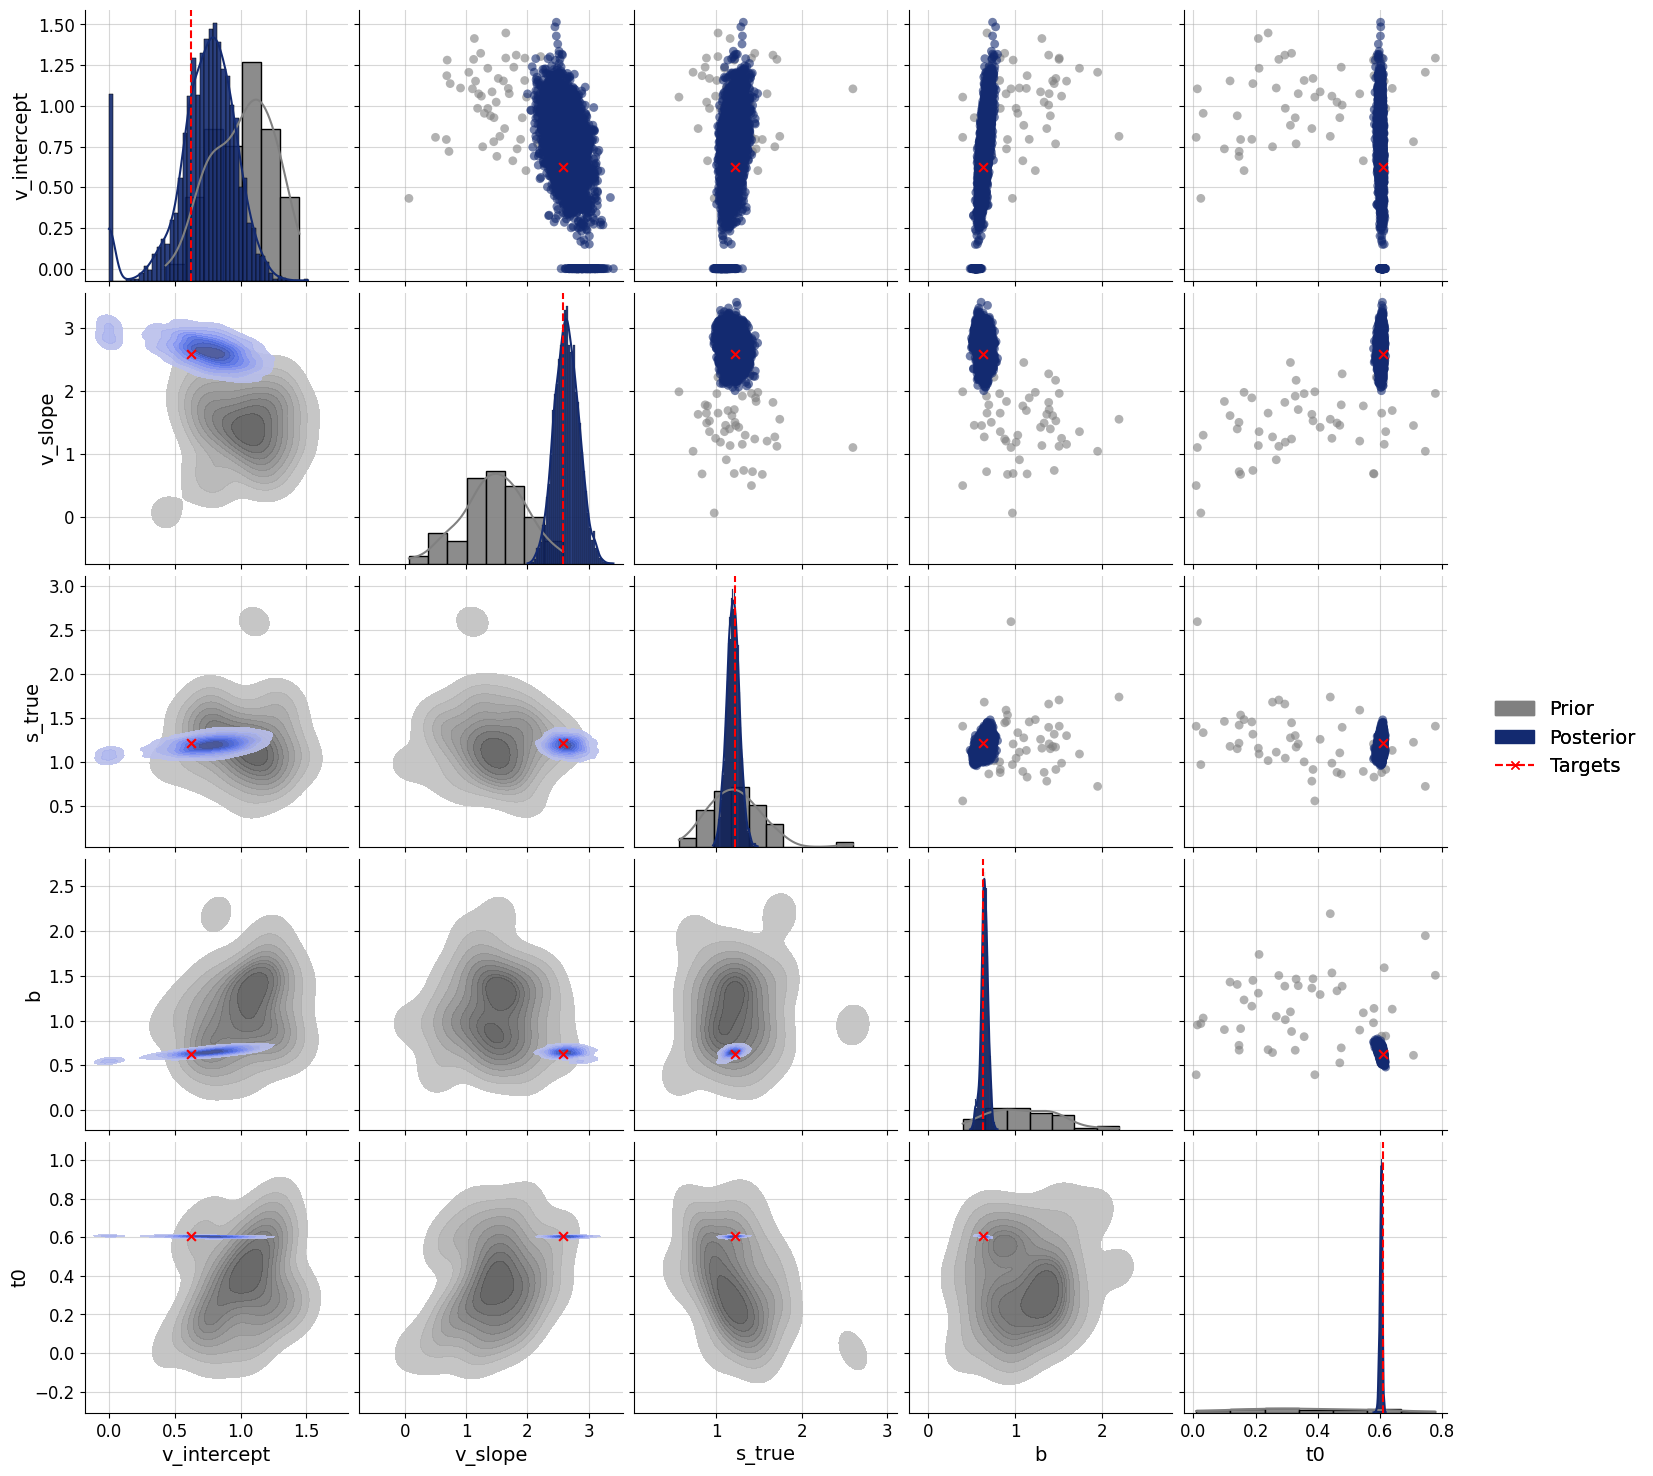

In [14]:
_ = bf.diagnostics.pairs_posterior(posterior_samples_approx[2], prior_samples[2], prior_samples, variable_names=param_names)

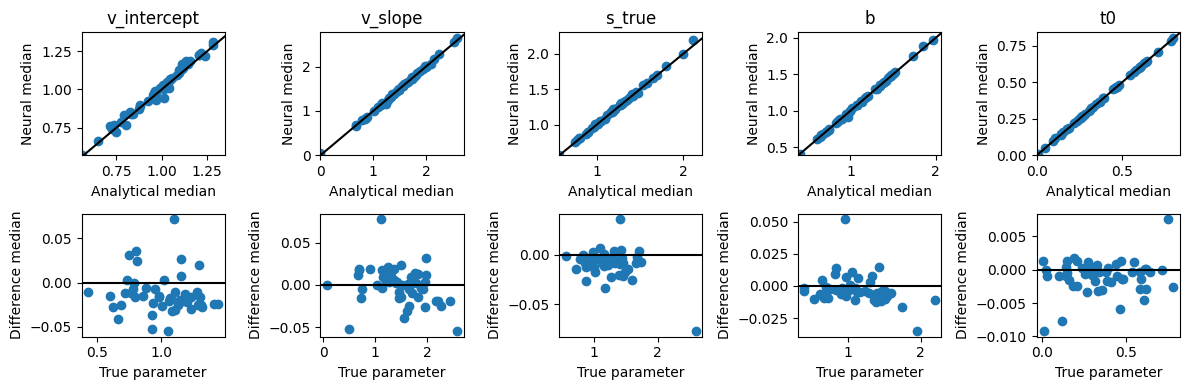

In [15]:
posterior_median_approx = np.median(posterior_samples_approx, axis=1)
posterior_median_ref = np.median(posterior_samples_ref, axis=1)

fig, axarr = plt.subplots(2, 5, figsize=(12, 4))

for i, param in enumerate(param_names):
    axarr[0, i].scatter(posterior_median_ref[:, i], posterior_median_approx[:, i])
    axarr[0, i].axline((0, 0), slope=1.0, color="black")
    axarr[0, i].set_xlim((posterior_median_ref[:, i].min(), None))
    axarr[0, i].set_ylim((posterior_median_approx[:, i].min(), None))
    axarr[0, i].set_xlabel("Analytical median")
    axarr[0, i].set_ylabel("Neural median")
    axarr[0, i].set_title(param)

    axarr[1, i].scatter(prior_samples[:, i], posterior_median_ref[:, i] - posterior_median_approx[:, i])
    axarr[1, i].axhline(color="black")
    axarr[1, i].set_xlabel("True parameter")
    axarr[1, i].set_ylabel("Difference median")

fig.tight_layout()
plt.savefig("parameter_recovery/rdm_diff_approx_ref.png")

## CRDM

In [16]:
param_names = ["v_c_intercept", "v_c_slope", "amp", "tau", "s_true", "b", "t0"]

results = load_hdf5("../outputs/crdm/model.dt=0.0005/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery.hdf5")
posterior_samples_chains_approx = results["samples_approx"]
posterior_samples_approx = reshape_posterior_samples(posterior_samples_chains_approx)

prior_samples = results["true_params"]
data = results["data"]

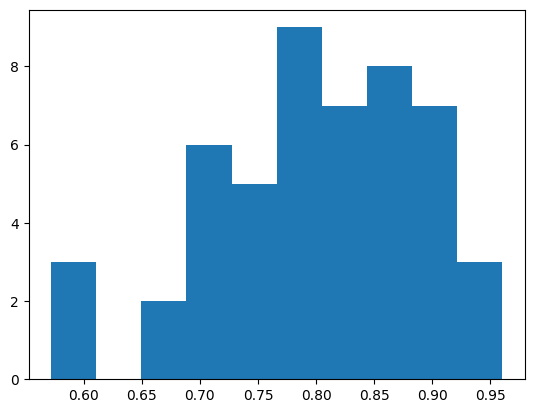

In [17]:
plt.hist(data[..., 1].mean(axis=1));

In [18]:
psrf_approx = blackjax.diagnostics.potential_scale_reduction(posterior_samples_chains_approx, chain_axis=2, sample_axis=1)
is_converged_approx = np.all(np.isfinite(psrf_approx) & (psrf_approx < 1.01), axis=1)
is_converged_approx.mean()

/home/mluken/Repositories/racing-diffusion-conflict/venv/lib/python3.11/site-packages/blackjax/diagnostics.py:72: RuntimeWarning: invalid value encountered in divide
  (between_chain_variance / within_chain_variance + num_samples - 1)


Array(0.76, dtype=float32)

In [19]:
psrf_approx

Array([[1.0005634 , 1.0011898 , 0.999877  , 1.0010648 , 1.0000916 ,
        0.9998866 , 1.0007495 ],
       [1.0213952 , 1.0149949 , 1.0068064 , 1.0016267 , 1.0004817 ,
        1.0047973 , 1.0080025 ],
       [1.0000587 , 0.99958867, 1.0006826 , 1.0004321 , 1.0006818 ,
        1.0010849 , 1.0004492 ],
       [0.9999246 , 0.99980116, 1.0002347 , 0.9997361 , 0.99967873,
        1.0002936 , 0.99960905],
       [1.0007429 , 1.000102  , 0.9995887 , 0.9998267 , 0.99964213,
        1.0008715 , 1.0006311 ],
       [0.9996039 , 0.99990517, 1.0013341 , 1.000587  , 1.0000694 ,
        0.9997612 , 0.9996357 ],
       [1.359148  , 1.2487872 , 1.2085052 , 1.3335505 , 1.0567796 ,
        1.0522764 , 1.0897744 ],
       [0.9999805 , 0.9998066 , 1.0001149 , 1.0012224 , 1.0002893 ,
        1.0011835 , 1.0005668 ],
       [1.0007969 , 0.99972355, 0.9998058 , 1.0004183 , 1.0002681 ,
        1.0001318 , 0.9997171 ],
       [1.0010153 , 1.000097  , 1.00015   , 1.0006441 , 0.99956053,
        1.0012287 , 1.0

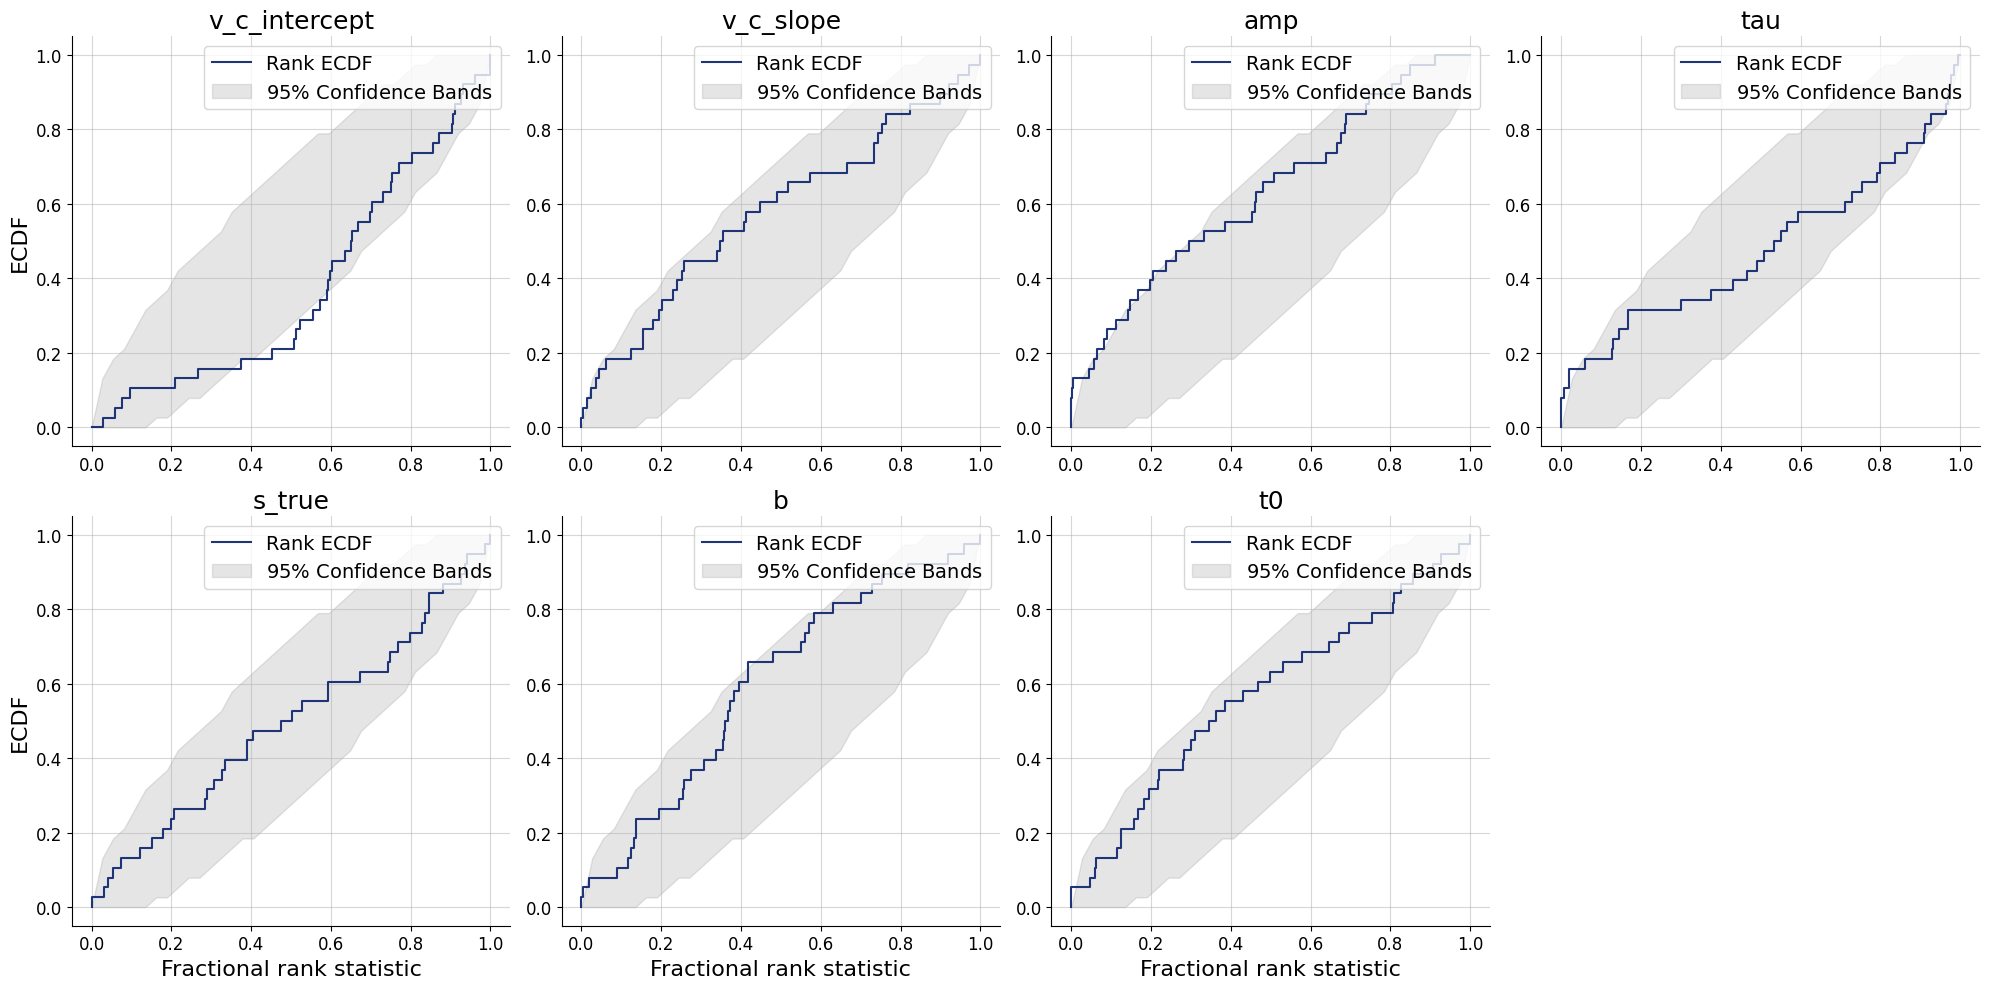

In [20]:
_ = bf.diagnostics.calibration_ecdf(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/crdm_ecdf_approx.png")

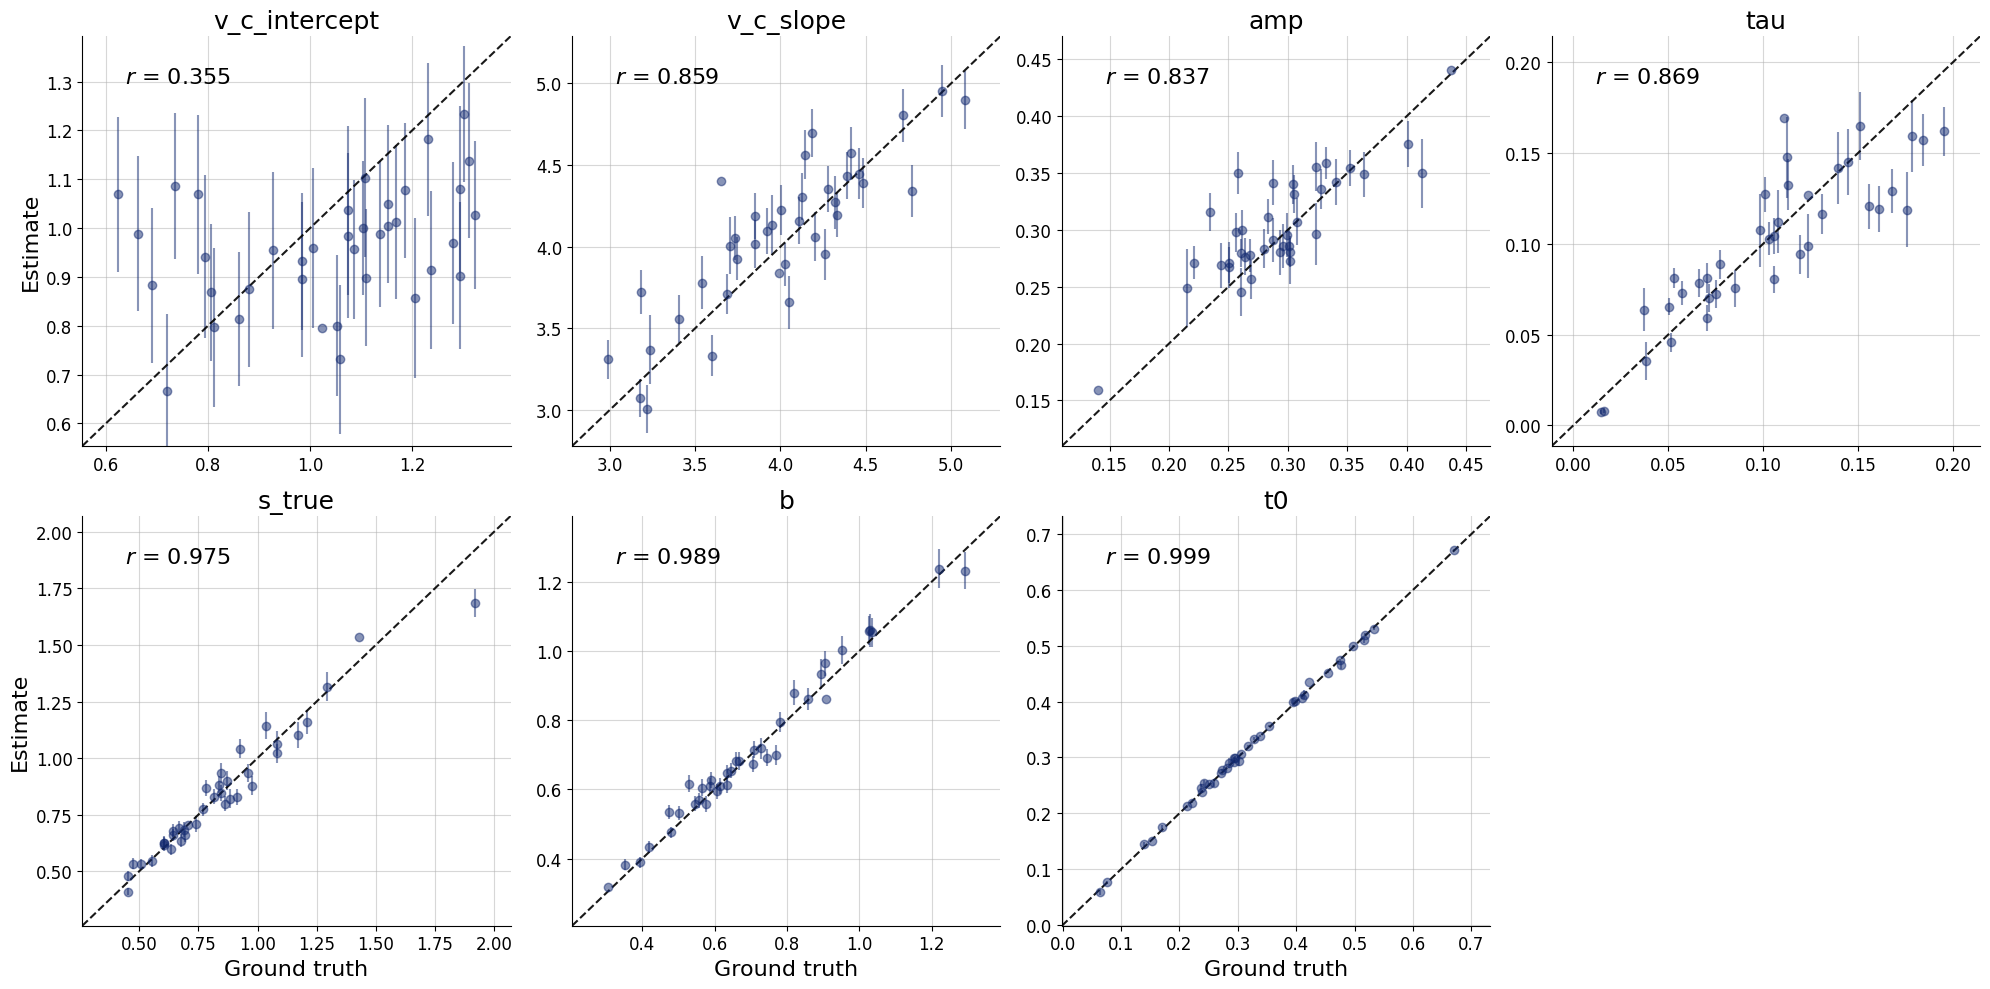

In [21]:
_ = bf.diagnostics.recovery(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names)
plt.savefig("parameter_recovery/crdm_recovery_approx.png")

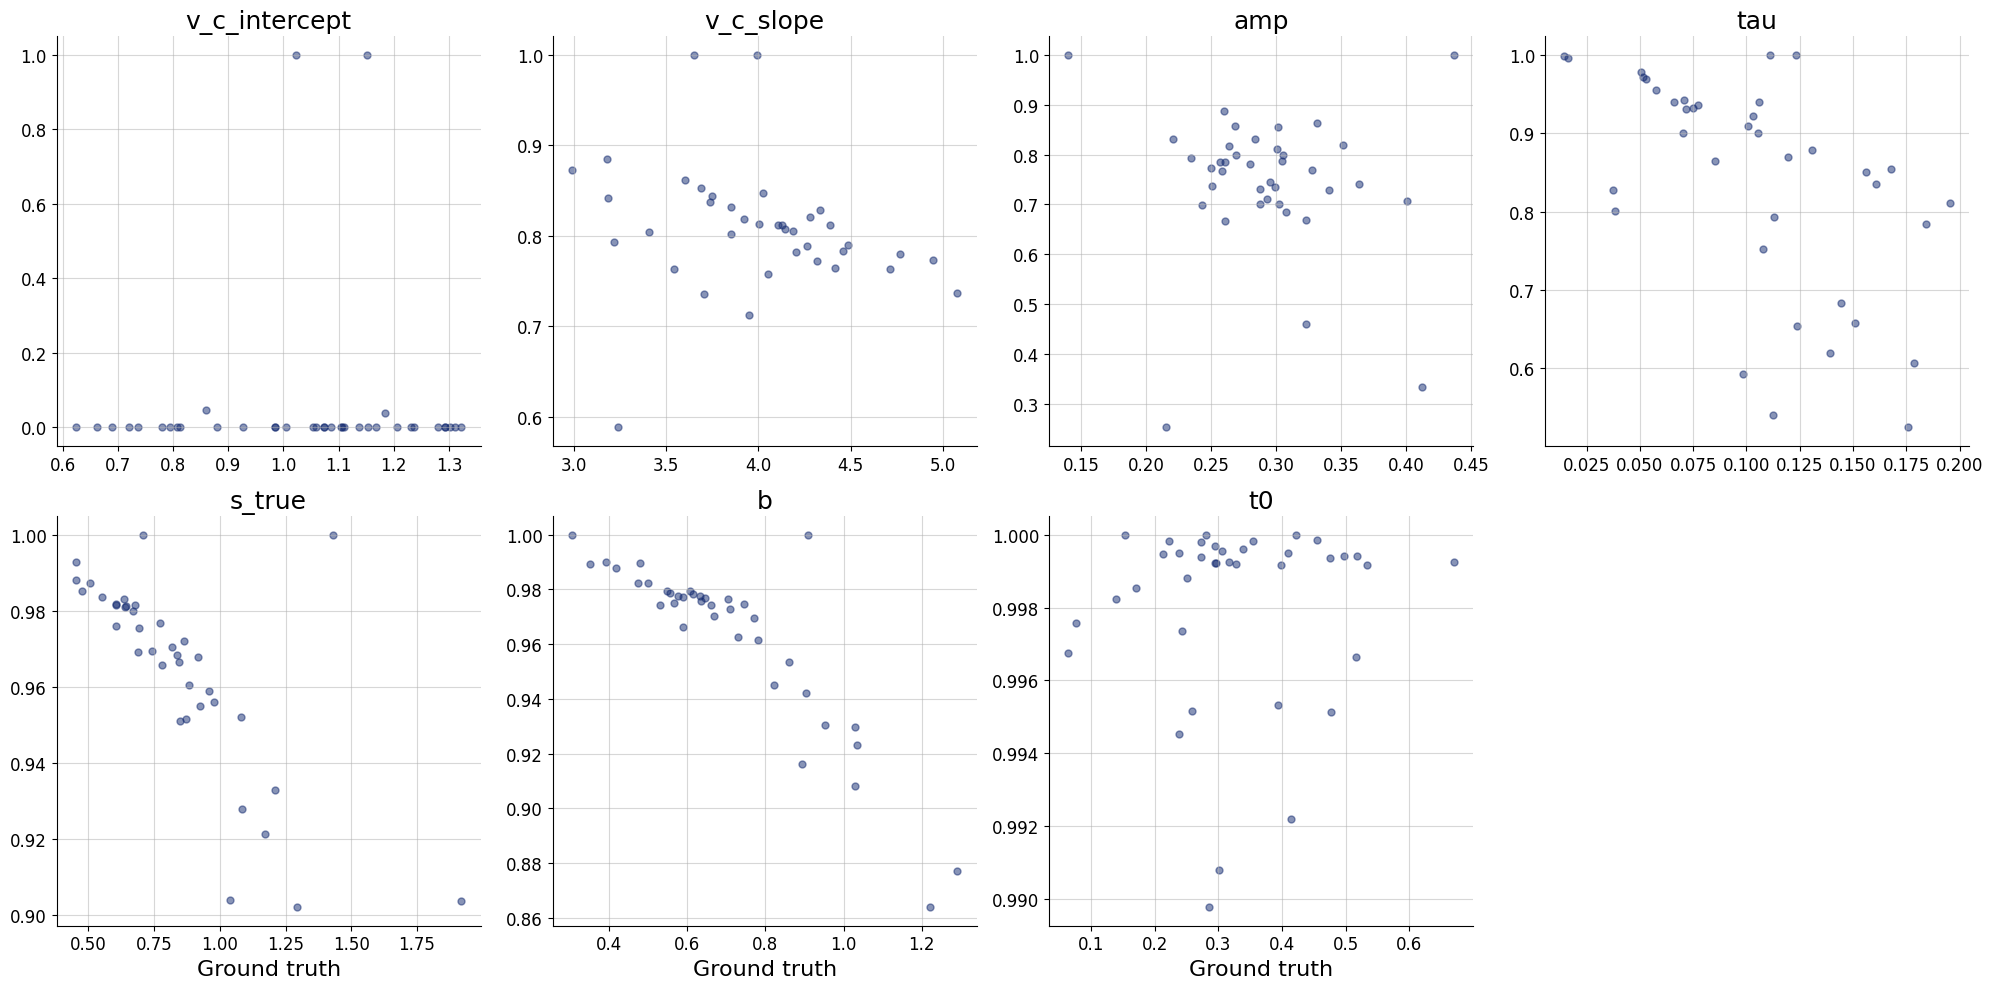

In [37]:
bf.diagnostics.plot_quantity(bf.diagnostics.posterior_contraction(posterior_samples_approx[is_converged_approx], prior_samples[is_converged_approx], variable_names=param_names, aggregation=None), prior_samples[is_converged_approx])
plt.savefig("parameter_recovery/crdm_pc_approx.png")

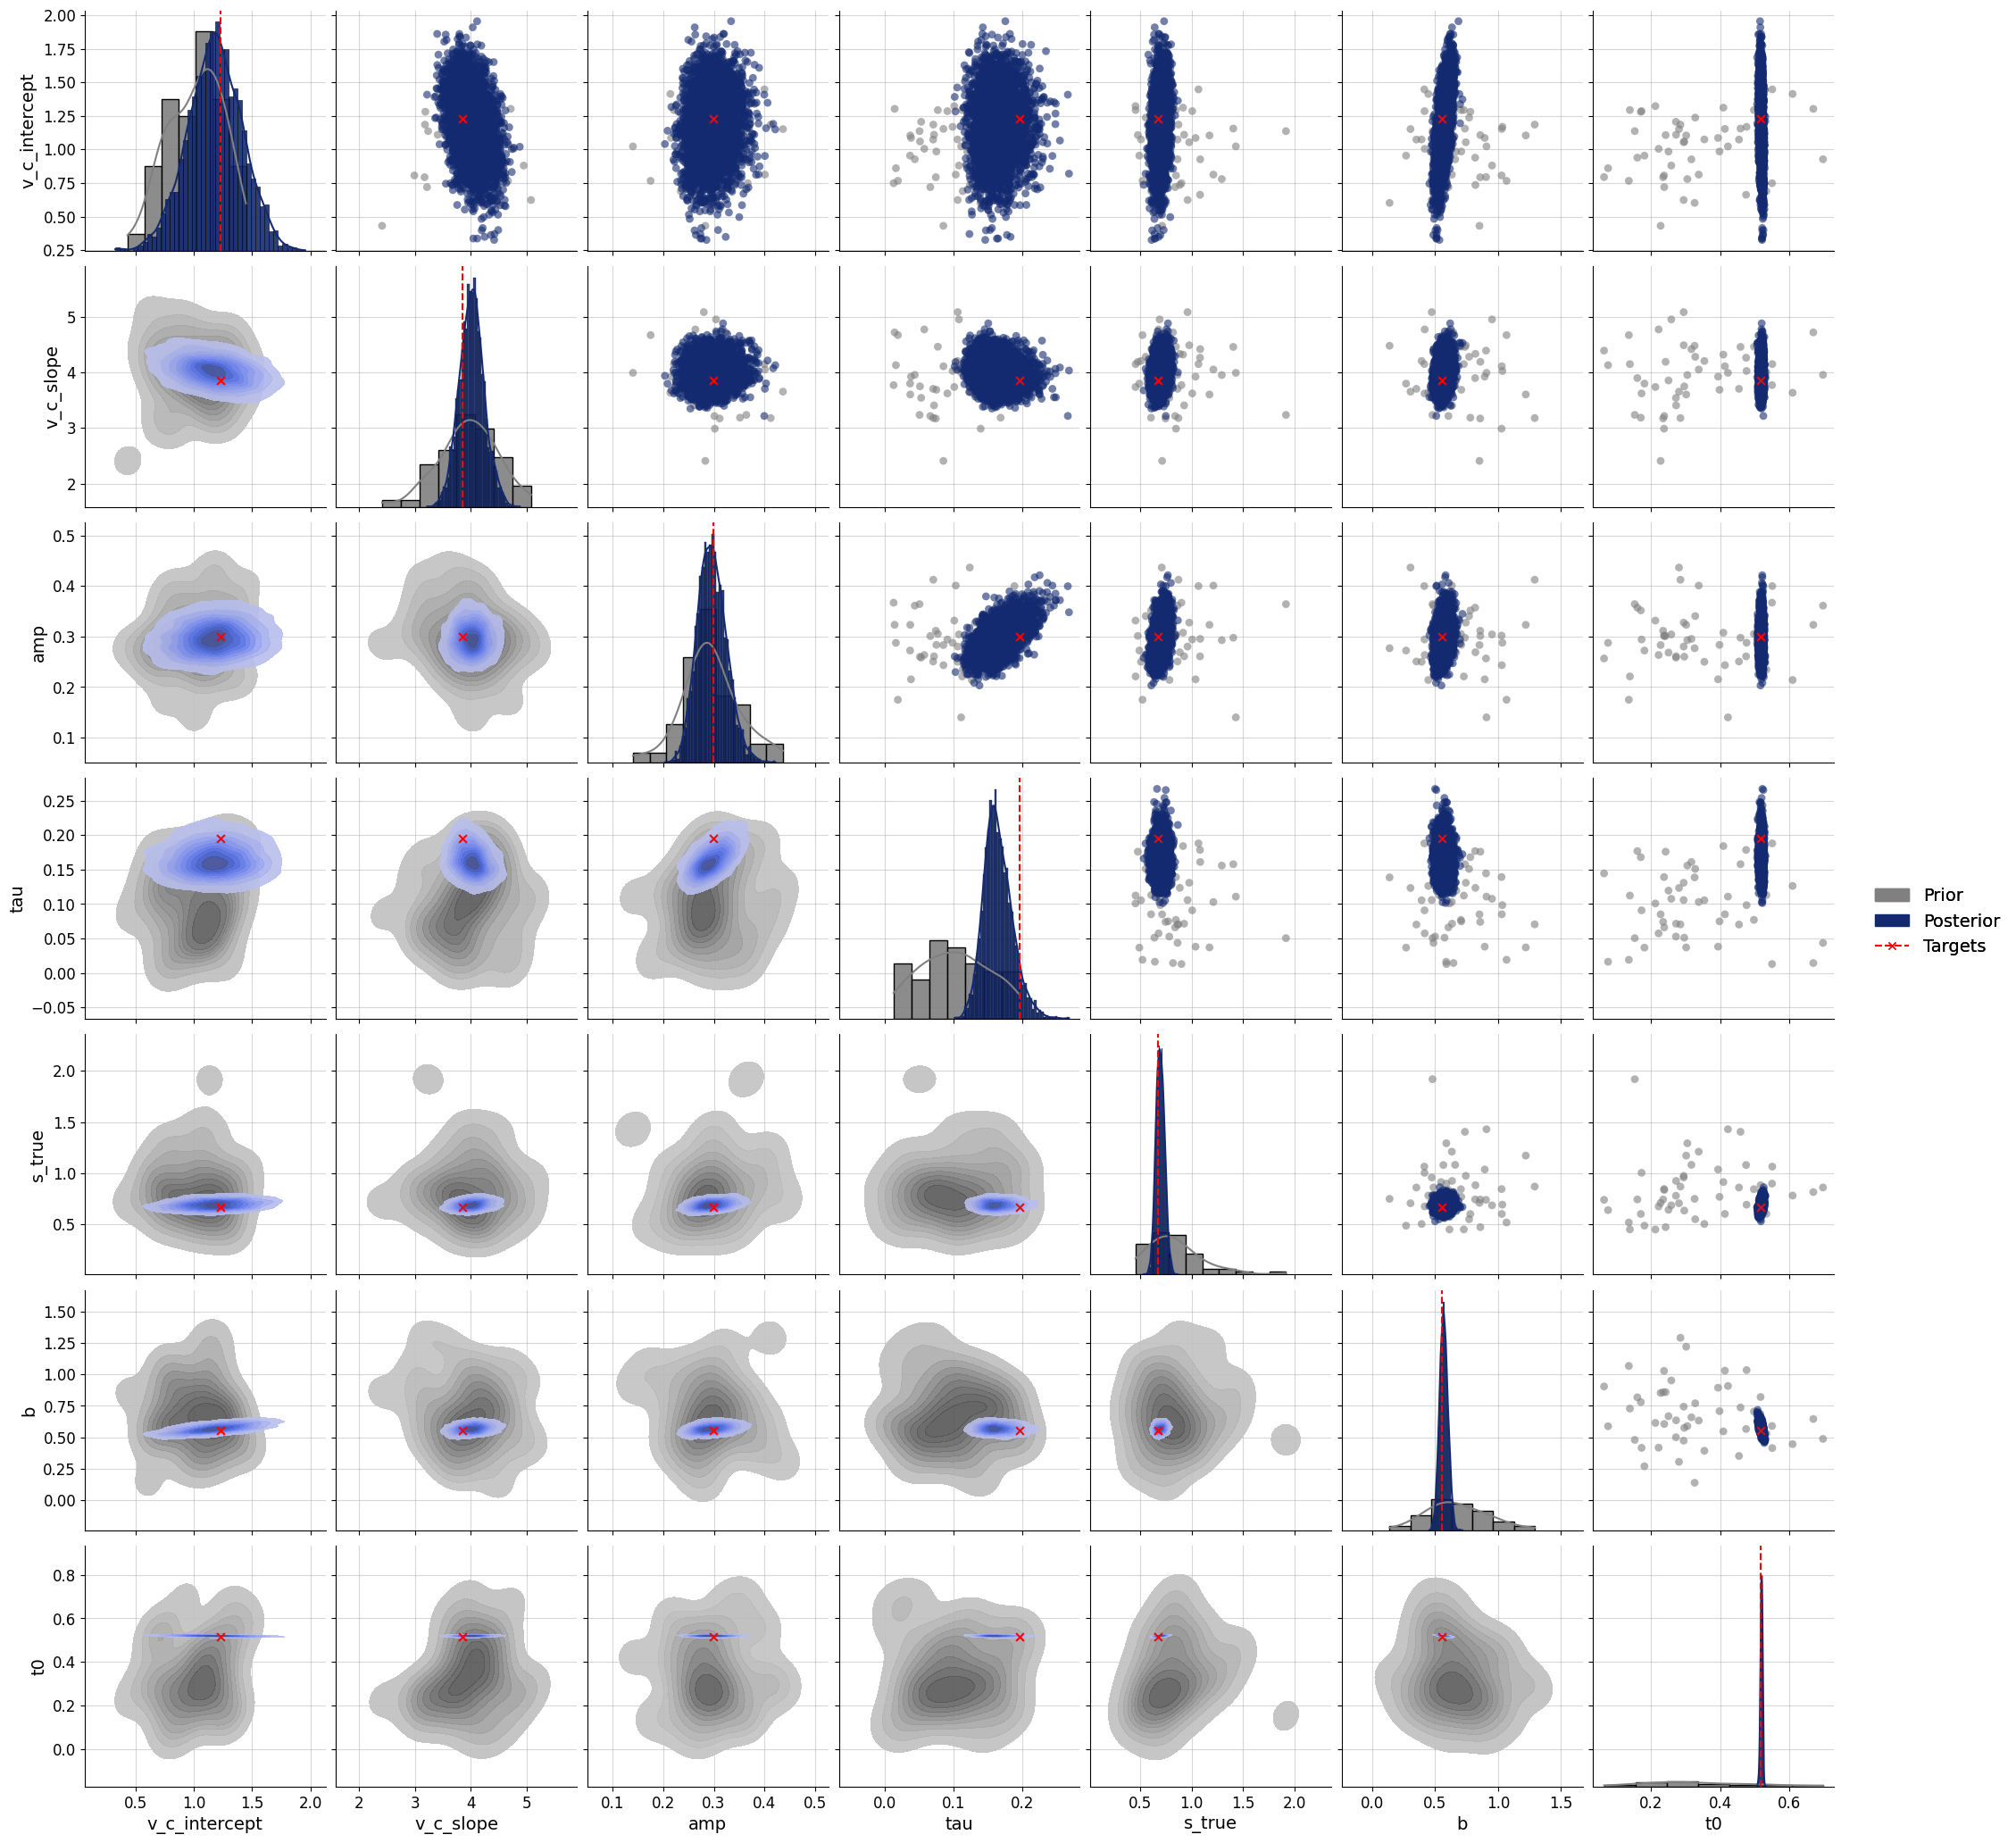

In [38]:
_ = bf.diagnostics.pairs_posterior(posterior_samples_approx[0], prior_samples[0], prior_samples, variable_names=param_names)